In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
import os
os.listdir('/kaggle/input')

['datasets']

In [4]:
os.listdir('/kaggle/input/datasets/spscientist/students-performance-in-exams')

['StudentsPerformance.csv']

In [5]:
df = pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
df.shape

(1000, 8)

In [9]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [10]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

there were no missing values, so no need to drop or fill them

In [11]:
df.columns = df.columns.str.lower()

In [12]:
df.columns = df.columns.str.replace(' ', '_')

In [13]:
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [14]:
df['parental_level_of_education'] = df['parental_level_of_education'].str.lower()

In [15]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [16]:
top10_students = df.sort_values(by='total_score', ascending=False).head(10)

In [17]:
top10_students

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
712,female,group D,some college,standard,none,98,100,99,297
179,female,group D,some high school,standard,completed,97,100,100,297
165,female,group C,bachelor's degree,standard,completed,96,100,100,296
625,male,group D,some college,standard,completed,100,97,99,296
685,female,group E,master's degree,standard,completed,94,99,100,293
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,293


In [18]:
df.groupby('gender')[['math_score','reading_score','writing_score']].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


* Out of the top 10 students with the highest marks, 80% are female students
* The average score in Reading and Writing is higher for female students than male students,whereas male students have a better average in Maths than female students

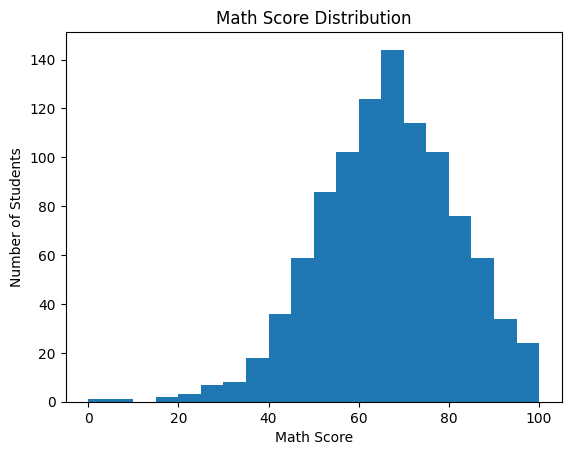

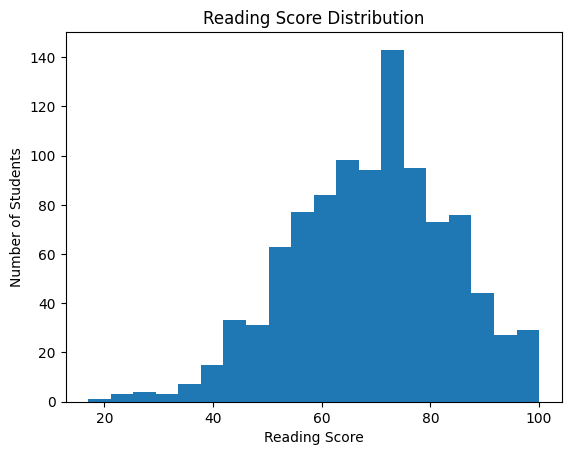

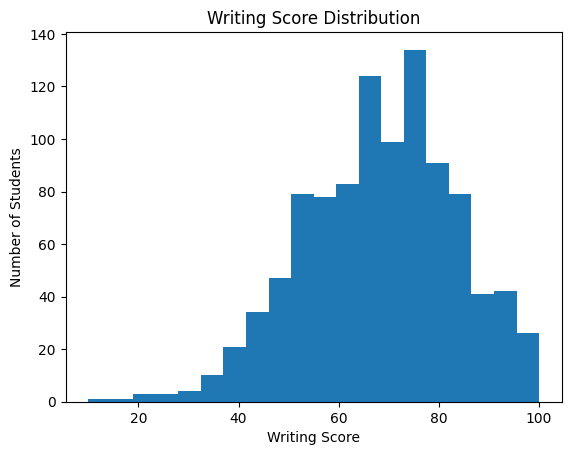

In [19]:
plt.figure()
plt.hist(df['math_score'], bins=20)
plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.show()

plt.figure()
plt.hist(df['reading_score'], bins=20)
plt.title('Reading Score Distribution')
plt.xlabel('Reading Score')
plt.ylabel('Number of Students')
plt.show()

plt.figure()
plt.hist(df['writing_score'], bins=20)
plt.title('Writing Score Distribution')
plt.xlabel('Writing Score')
plt.ylabel('Number of Students')
plt.show()

The score distribution suggests that most of the students scored in the upper middle range(60-80), with very few students in the extreme low or extreme high marks category.

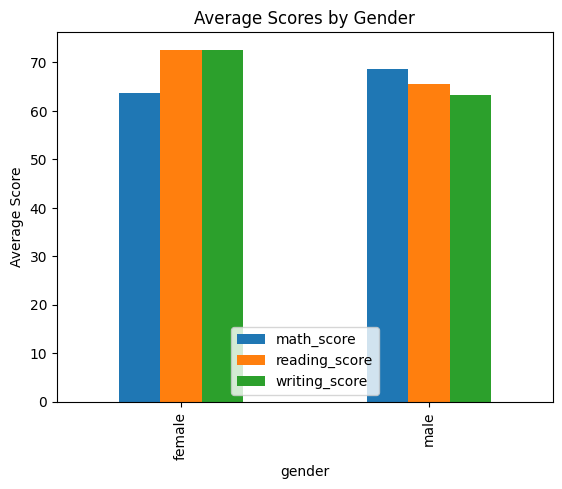

In [20]:
avg_scores = df.groupby('gender')[['math_score','reading_score','writing_score']].mean()

avg_scores.plot(kind='bar')

plt.title('Average Scores by Gender')
plt.ylabel('Average Score')

plt.show()

From the bar chart of average scores by gender, female students perform better in reading and writing, while maths scores are higher for male students.

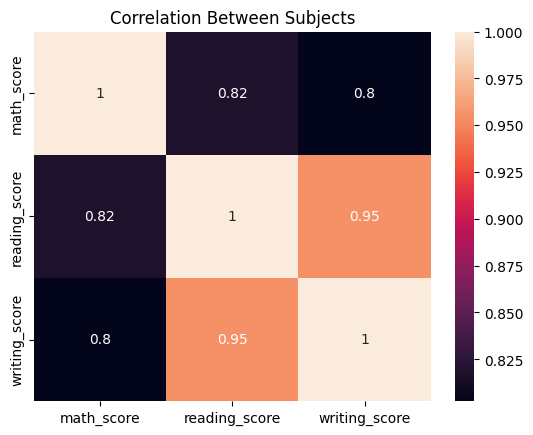

In [21]:
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(), annot=True)

plt.title('Correlation Between Subjects')
plt.show()

The correlation heatmap shows that reading and writing scores are highly correlated (0.95), meaning that students who perform well in reading also perform well in writing. Math scores also show a positive correlation with the other subjects(0.82 and 0.8).

In [22]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

The coulumn called total score of a student which is the summation of scores in individual scores in all subjects can be an important factor in Machine learning models. It represents the overall academic performance of a student which might help to improve the model performance.

In [23]:
df['test_preparation_course'] = df['test_preparation_course'].map({'completed':1, 'none':0})

In [24]:
df = pd.get_dummies(df,columns=['gender','race/ethnicity','parental_level_of_education','lunch'],
                    drop_first=True)

Categorical columns were converted into numerical form so they can be used by machine learning models. The test_preparation_course column was encoded using binary mapping (completed = 1, none = 0). Other categorical features such as gender, race, parental education, and lunch type were converted using one-hot encoding to avoid introducing any artificial ordering between categories.

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['math_score','reading_score','writing_score','total_score']] = scaler.fit_transform(
    df[['math_score','reading_score','writing_score','total_score']]
)

Numerical features were scaled using MinMaxScalar. Scaling standardizes the data so that each feature falls in the range of 0 and 1. This is important because many machine learning algorithms can be affected by the scale of input features, and scaling helps that all features contribute equally to the model. MinMaxScalar was prefered over Standard Scalar because neural networks work better with the first one.

In [32]:
df.to_csv('processed.csv', index=False)

In [33]:
pd.read_csv('processed.csv').head()

,test_preparation_course,math_score,reading_score,writing_score,total_score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard
0,0,0.72,0.662651,0.711111,0.699634,False,True,False,False,False,True,False,False,False,False,True
1,1,0.69,0.879518,0.866667,0.805861,False,False,True,False,False,False,False,False,True,False,True
2,0,0.90,0.939759,0.922222,0.919414,False,True,False,False,False,False,False,True,False,False,True
3,0,0.47,0.481928,0.377778,0.443223,True,False,False,False,False,False,False,False,False,False,False
4,0,0.76,0.734940,0.722222,0.739927,True,False,True,False,False,False,False,False,True,False,True
